In [ ]:
from google.colab import files
uploaded = files.upload()


Saving thermo_full_11927.csv to thermo_full_11927.csv


In [ ]:
import pandas as pd

df = pd.read_csv('thermo_full_11927.csv')

print("Shape (rows, columns):", df.shape)
print("\nColumns:")
for c in df.columns:
    print("  ", c)

df.head()      # shows the first 5 rows

Shape (rows, columns): (11927, 19)

Columns:
   name
   ZT_values
   electrical_conductivity
   electrical_resistivity
   seebeck_coefficient
   power_factor
   thermal_conductivity
   compound_type
   crystal_structure
   lattice_structure
   unit
   space_group
   processing_method
   material_name
   lattice_parameters.a
   lattice_parameters.b
   lattice_parameters.c
   doping.doping_type
   doping.dopants


,name,ZT_values,electrical_conductivity,electrical_resistivity,seebeck_coefficient,power_factor,thermal_conductivity,compound_type,crystal_structure,lattice_structure,unit,space_group,processing_method,material_name,lattice_parameters.a,lattice_parameters.b,lattice_parameters.c,doping.doping_type,doping.dopants
0,CdS,"[{'value': 0.686, 'ZT_temperature': 300, 'ZT_t...","[{'σ_value': 1.268, 'σ_unit': '10^18 Ω^-1 m^-1...",NaN,"[{'S_value': 211.963, 'S_unit': 'μV/K', 'S_Tem...",NaN,"[{'κ_value': 2.49e-15, 'κ_unit': 'W/mK s', 'κ_...",NaN,planar honeycomb,NaN,Å,P-6m2,NaN,CdS,4.257,4.257,NaN,transition metals,NaN
1,FeSi1.95Se0.05,NaN,NaN,"[{'ρ_value': 40.1, 'ρ_unit': 'μΩ m', 'ρ_Temper...",NaN,NaN,NaN,NaN,orthorhombic,NaN,NaN,71-0642,hot-pressing,FeSi1.95Se0.05,NaN,NaN,NaN,Se doping,['Se']
2,Cu2Sn0.9In0.1S3,"[{'value': 0.6, 'ZT_temperature': 773, 'ZT_tem...",NaN,NaN,NaN,NaN,NaN,ternary chalcogenide doped,NaN,NaN,NaN,NaN,NaN,Cu2Sn0.9In0.1S3,NaN,NaN,NaN,doping,['In']
3,Ca0.9Yb0.1MnO3,NaN,NaN,NaN,NaN,"[{'PF_value': 0.00011, 'PF_unit': 'W m^-1 K^-2...",NaN,oxide,NaN,NaN,NaN,NaN,spark plasma sintering at 750 °C at 50 MPa in ...,Ca0.9Yb0.1MnO3,NaN,NaN,NaN,substitutional,['Yb']
4,Na0.2Cu1.8S,"[{'value': 0.4, 'ZT_temperature': 150, 'ZT_tem...","[{'σ_value': 500, 'σ_unit': 'S/cm', 'σ_Tempera...",NaN,NaN,"[{'PF_value': 250, 'PF_unit': 'μW K⁻2 m⁻1', 'P...","[{'κ_value': 0.3, 'κ_unit': 'W m⁻1 K⁻1', 'κ_Te...",superionic conductor,orthorhombic,orthorhombic,Å,P*n* (orthorhombic djurleite),synthesized in mixed melt medium of NaOH and K...,Na0.2Cu1.8S,26.9,15.72,13.57,substitutional,['Na']


In [ ]:
# Look at ONE material's ZT_values cell, raw
print(type(df['ZT_values'][0]))   # what Python thinks this is
print(df['ZT_values'][0])         # the raw text

<class 'str'>
[{'value': 0.686, 'ZT_temperature': 300, 'ZT_temperature_unit': 'K'}, {'value': 0.621, 'ZT_temperature': 1200, 'ZT_temperature_unit': 'K'}]


In [ ]:
import ast

# ast.literal_eval safely turns the text "[{...}]" into a real list of dicts
zt_list = ast.literal_eval(df['ZT_values'][0])

print("Number of measurements:", len(zt_list))
print("First measurement:", zt_list[0])
print("Just the value:", zt_list[0]['value'])
print("Just the temperature:", zt_list[0]['ZT_temperature'])

Number of measurements: 2
First measurement: {'value': 0.686, 'ZT_temperature': 300, 'ZT_temperature_unit': 'K'}
Just the value: 0.686
Just the temperature: 300


In [ ]:
# Properties we want coverage for (exact column names from your file)
cols = [
    'ZT_values', 'seebeck_coefficient', 'electrical_conductivity',
    'electrical_resistivity', 'power_factor', 'thermal_conductivity',
    'compound_type', 'crystal_structure', 'lattice_structure',
    'space_group', 'processing_method', 'doping.doping_type', 'doping.dopants'
]

total = len(df)
coverage = (df[cols].notna().sum() / total * 100).round(1)   # % non-empty per column
coverage = coverage.sort_values(ascending=False)             # highest first
print(coverage)

compound_type              78.5
crystal_structure          74.8
lattice_structure          63.3
ZT_values                  62.8
processing_method          59.5
doping.doping_type         57.8
space_group                47.4
thermal_conductivity       44.1
doping.dopants             41.4
seebeck_coefficient        39.5
power_factor               29.8
electrical_conductivity    25.8
electrical_resistivity     11.7
dtype: float64


compound_type              78.5
crystal_structure          74.8
lattice_structure          63.3
ZT_values                  62.8
processing_method          59.5
doping.doping_type         57.8
space_group                47.4
thermal_conductivity       44.1
doping.dopants             41.4
seebeck_coefficient        39.5
power_factor               29.8
electrical_conductivity    25.8
electrical_resistivity     11.7
dtype: float64


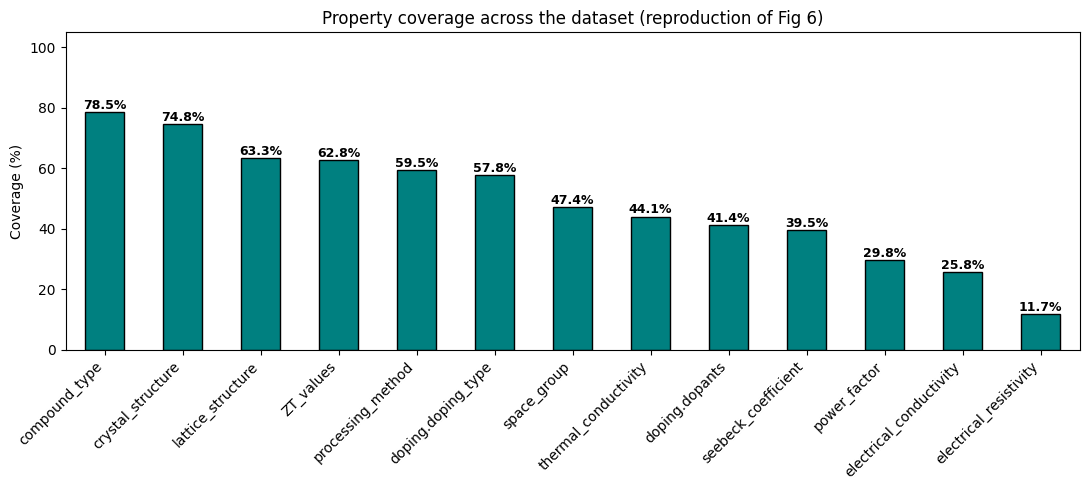

In [ ]:
import matplotlib.pyplot as plt

cols = [
    'ZT_values', 'seebeck_coefficient', 'electrical_conductivity',
    'electrical_resistivity', 'power_factor', 'thermal_conductivity',
    'compound_type', 'crystal_structure', 'lattice_structure',
    'space_group', 'processing_method', 'doping.doping_type', 'doping.dopants'
]

total = len(df)
coverage = (df[cols].notna().sum() / total * 100).round(1)
coverage = coverage.sort_values(ascending=False)
print(coverage)

plt.figure(figsize=(11, 5))
coverage.plot(kind='bar', color='teal', edgecolor='black')
plt.ylabel('Coverage (%)')
plt.title('Property coverage across the dataset (reproduction of Fig 6)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(coverage):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=9, fontweight='bold')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [ ]:
import ast
import numpy as np

zt_all = []                                   # will hold every ZT value in the dataset
for cell in df['ZT_values'].dropna():         # skip materials with no ZT
    measurements = ast.literal_eval(cell)     # text -> real list of dicts
    for m in measurements:                    # each measurement dict
        v = m.get('value')                    # pull the ZT number
        if v is not None:
            zt_all.append(v)

zt_all = np.array(zt_all)

print("Total ZT values collected:", len(zt_all))
print("Mean ZT   :", round(zt_all.mean(), 3))
print("Median ZT :", round(np.median(zt_all), 3))
print("Std dev   :", round(zt_all.std(), 3))

Total ZT values collected: 11245


TypeError: the resolved dtypes are not compatible with add.reduce. Resolved (dtype('<U38'), dtype('<U38'), dtype('<U76'))

In [ ]:
import ast
import numpy as np

zt_all = []
skipped = 0
for cell in df['ZT_values'].dropna():
    try:
        measurements = ast.literal_eval(cell)
    except Exception:
        continue
    for m in measurements:
        v = m.get('value')
        try:
            v = float(v)          # force to a number
            zt_all.append(v)
        except (TypeError, ValueError):
            skipped += 1          # not convertible -> count it and move on

zt_all = np.array(zt_all, dtype=float)   # dtype=float guarantees a numeric array

print("Total ZT values collected:", len(zt_all))
print("Skipped (non-numeric)   :", skipped)
print("Mean ZT   :", round(zt_all.mean(), 3))
print("Median ZT :", round(np.median(zt_all), 3))
print("Std dev   :", round(zt_all.std(), 3))

Total ZT values collected: 11239
Skipped (non-numeric)   : 146
Mean ZT   : 1.355
Median ZT : 0.75
Std dev   : 17.708


In [ ]:
import ast
import numpy as np

zt_all = []
for cell in df['ZT_values'].dropna():
    try:
        measurements = ast.literal_eval(cell)
    except Exception:
        continue
    for m in measurements:
        try:
            v = float(m.get('value'))
        except (TypeError, ValueError):
            continue
        if 0 < v <= 6:            # keep only physically plausible ZT (paper's range)
            zt_all.append(v)

zt_all = np.array(zt_all, dtype=float)

print("Kept (physical 0 < ZT <= 6):", len(zt_all))
print("Mean ZT   :", round(zt_all.mean(), 3))
print("Median ZT :", round(np.median(zt_all), 3))
print("Std dev   :", round(zt_all.std(), 3))

Kept (physical 0 < ZT <= 6): 11192
Mean ZT   : 0.824
Median ZT : 0.75
Std dev   : 0.656


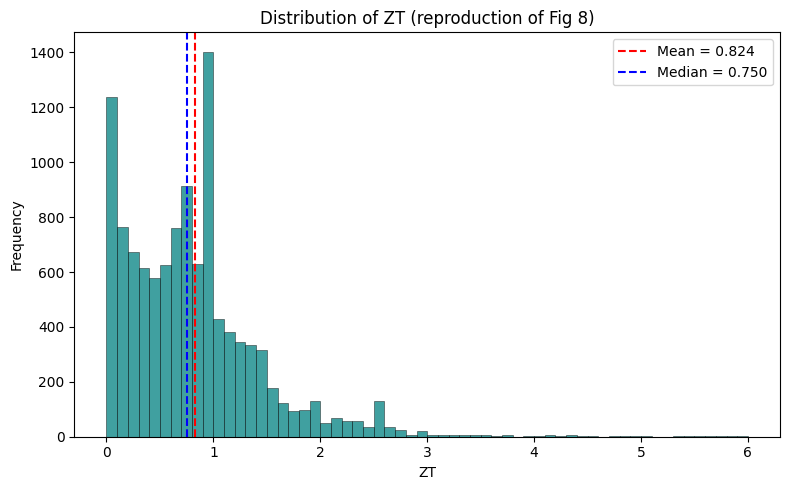

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(zt_all, bins=60, color='teal', alpha=0.75, edgecolor='black', linewidth=0.4)

# mark mean (red) and median (blue), like the paper's Fig 8
plt.axvline(zt_all.mean(),  color='red',  linestyle='--', label=f'Mean = {zt_all.mean():.3f}')
plt.axvline(np.median(zt_all), color='blue', linestyle='--', label=f'Median = {np.median(zt_all):.3f}')

plt.xlabel('ZT')
plt.ylabel('Frequency')
plt.title('Distribution of ZT (reproduction of Fig 8)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import re

def normalize_doping(s):
    if not isinstance(s, str): return s
    x = s.strip().lower()
    if re.fullmatch(r'n[- ]?type|n', x): return 'n-type'
    if re.fullmatch(r'p[- ]?type|p', x): return 'p-type'
    if re.search(r'(n.*p|p.*n)[- ]?type', x): return 'n+p-type'
    return x

def normalize_crystal(s):
    if not isinstance(s, str): return s
    x = s.strip().lower()
    if re.search(r'face[- ]?cent|fcc', x): return 'fcc'
    if re.search(r'rock[- ]?salt|nacl', x): return 'rock-salt'
    return x

df['doping_norm']  = df['doping.doping_type'].map(normalize_doping)
df['crystal_norm'] = df['crystal_structure'].map(normalize_crystal)

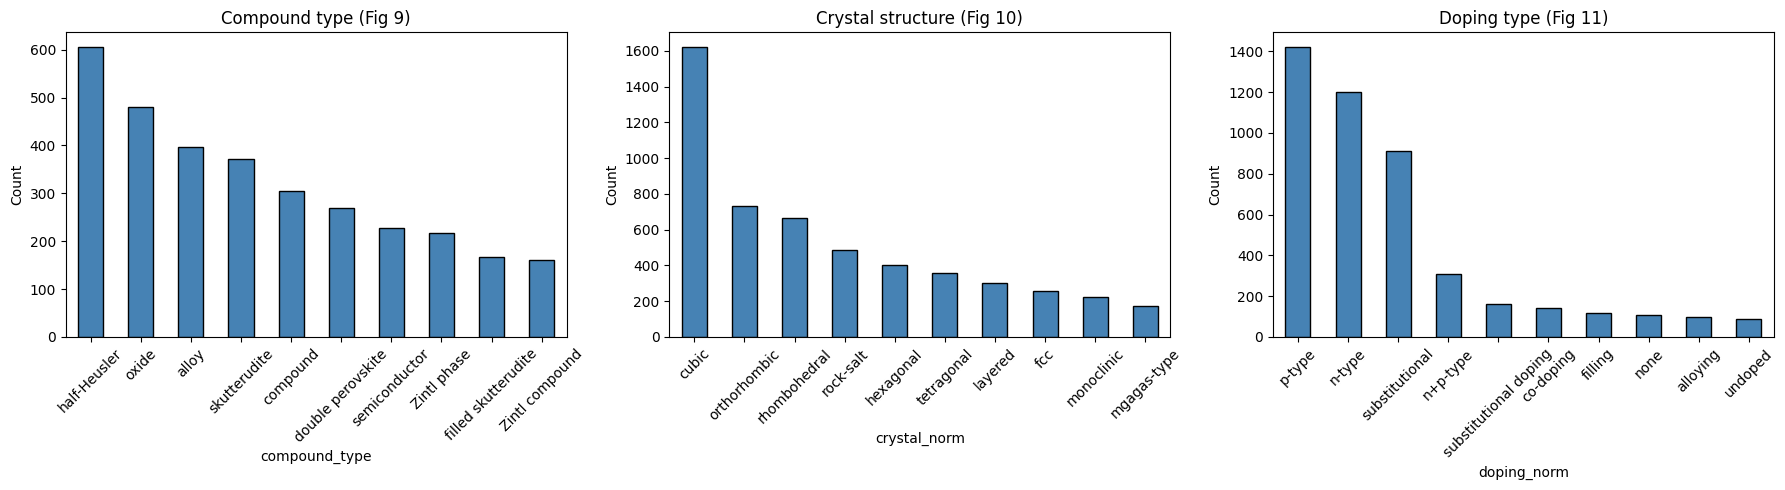

In [ ]:
import matplotlib.pyplot as plt

charts = {
    'Compound type (Fig 9)':  df['compound_type'].dropna().str.strip(),
    'Crystal structure (Fig 10)': df['crystal_norm'].dropna(),
    'Doping type (Fig 11)':   df['doping_norm'].dropna(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, series) in zip(axes, charts.items()):
    top10 = series.value_counts().head(10)     # the 10 most common, with counts
    top10.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def normalize_compound(s):
    if not isinstance(s, str): return s
    x = s.strip().lower()
    if 'zintl' in x: return 'Zintl'                       # merges "Zintl phase" + "Zintl compound"
    if 'skutterudite' in x: return 'skutterudite'         # merges "filled skutterudite" too
    if 'perovskite' in x: return 'perovskite'             # merges "double perovskite"
    if 'half-heusler' in x or 'half heusler' in x: return 'half-Heusler'
    return x

df['compound_norm'] = df['compound_type'].map(normalize_compound)

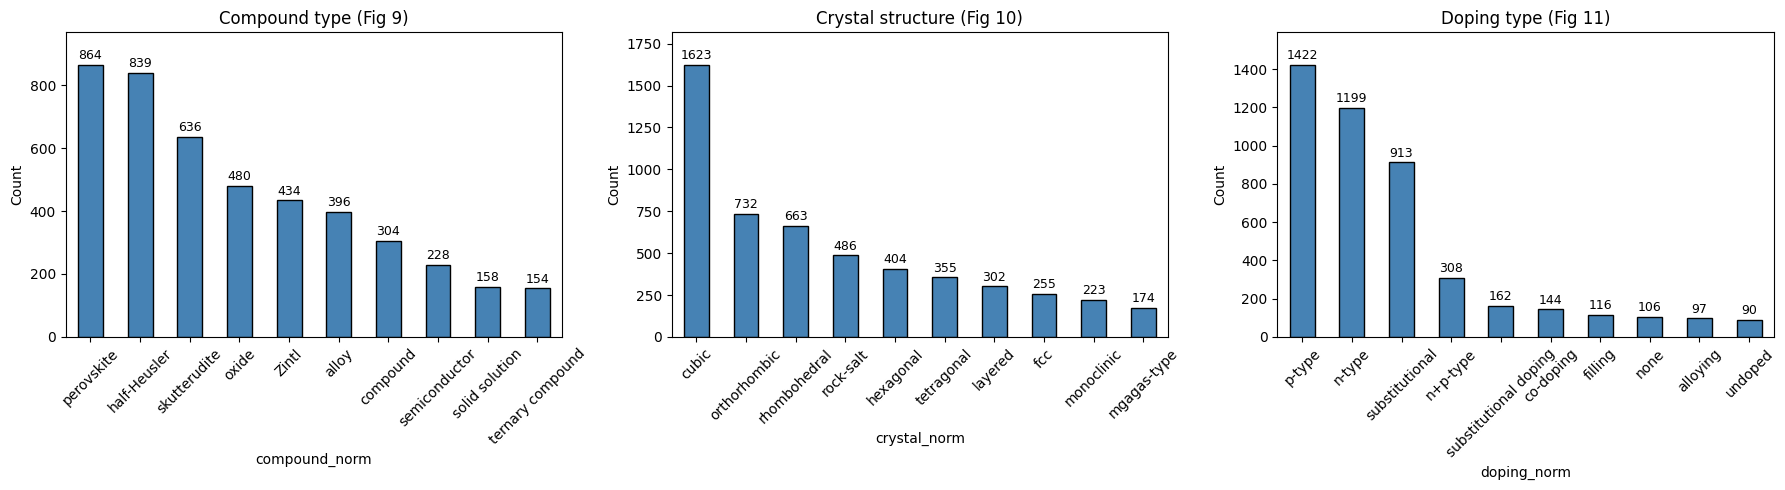

In [ ]:
import matplotlib.pyplot as plt

charts = {
    'Compound type (Fig 9)':      df['compound_norm'].dropna(),
    'Crystal structure (Fig 10)': df['crystal_norm'].dropna(),
    'Doping type (Fig 11)':       df['doping_norm'].dropna(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, series) in zip(axes, charts.items()):
    top10 = series.value_counts().head(10)
    bars = top10.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.bar_label(bars.containers[0], padding=2, fontsize=9)   # <-- count on top of each bar
    ax.margins(y=0.12)                                        # headroom so labels don't clip
plt.tight_layout()
plt.show()

In [ ]:
import ast

prop_temp_keys = {
    'ZT_values':               'ZT_temperature',
    'seebeck_coefficient':     'S_Temperature',
    'electrical_conductivity': 'σ_Temperature',
    'electrical_resistivity':  'ρ_Temperature',
    'power_factor':            'PF_Temperature',
    'thermal_conductivity':    'κ_Temperature',
}

fig7_counts = {}
for col, temp_key in prop_temp_keys.items():
    with_t, without_t = 0, 0
    for cell in df[col].dropna():
        try:
            measurements = ast.literal_eval(cell)
        except Exception:
            continue
        if not isinstance(measurements, list):
            continue
        for m in measurements:
            if not isinstance(m, dict):
                continue
            t = m.get(temp_key)
            if t is not None and str(t).strip() != '':
                with_t += 1
            else:
                without_t += 1
    fig7_counts[col] = {'with_temp': with_t, 'without_temp': without_t}

for col, c in fig7_counts.items():
    print(f"{col:28s} with_T={c['with_temp']:6d}  without_T={c['without_temp']:6d}  total={c['with_temp']+c['without_temp']:6d}")

ZT_values                    with_T=  9649  without_T=  1736  total= 11385
seebeck_coefficient          with_T=  6850  without_T=  1253  total=  8103
electrical_conductivity      with_T=  4225  without_T=   871  total=  5096
electrical_resistivity       with_T=  1699  without_T=   384  total=  2083
power_factor                 with_T=  4383  without_T=   853  total=  5236
thermal_conductivity         with_T=  7303  without_T=  1649  total=  8952


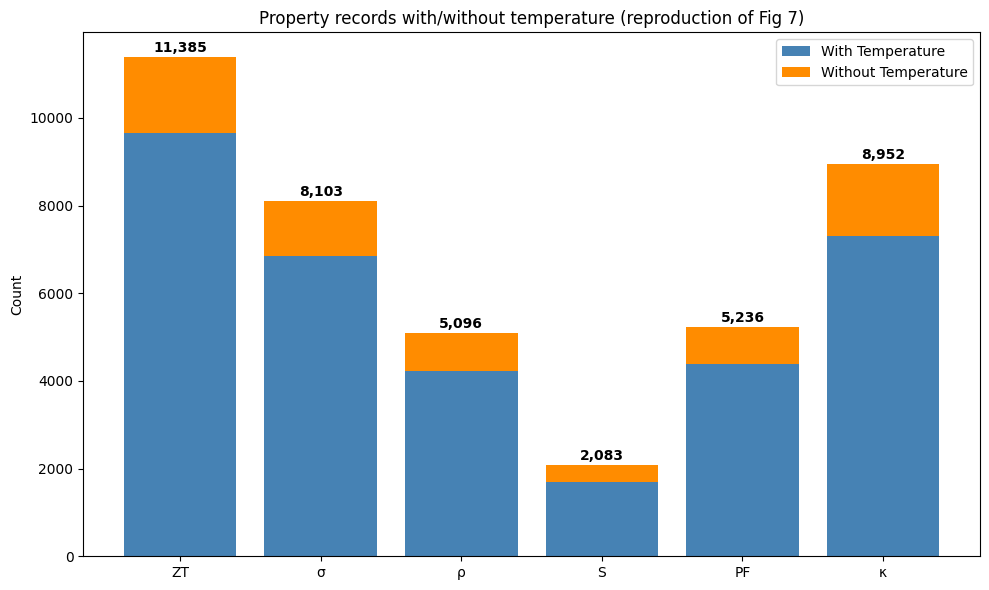

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(fig7_counts.keys())
with_t = [fig7_counts[c]['with_temp'] for c in labels]
without_t = [fig7_counts[c]['without_temp'] for c in labels]
totals = [w+wo for w, wo in zip(with_t, without_t)]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x, with_t, label='With Temperature', color='steelblue')
ax.bar(x, without_t, bottom=with_t, label='Without Temperature', color='darkorange')
for i, tot in enumerate(totals):
    ax.text(i, tot + max(totals)*0.01, f"{tot:,}", ha='center', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['ZT','σ','ρ','S','PF','κ'])
ax.set_ylabel('Count')
ax.set_title('Property records with/without temperature (reproduction of Fig 7)')
ax.legend()
plt.tight_layout()
plt.show()

Alloy points: 368
Oxide points: 366


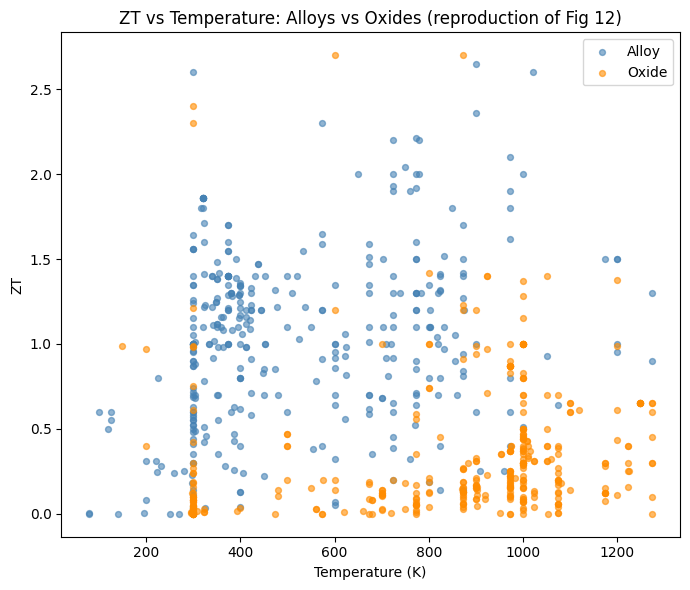

In [ ]:
def get_zt_points(row):
    """Returns list of (T_kelvin, ZT) for one row, bounded to physical ZT range."""
    points = []
    cell = row['ZT_values']
    if pd.isna(cell):
        return points
    try:
        measurements = ast.literal_eval(cell)
    except Exception:
        return points
    if not isinstance(measurements, list):
        return points
    for m in measurements:
        if not isinstance(m, dict):
            continue
        try:
            v = float(m.get('value'))
        except (TypeError, ValueError):
            continue
        if not (0 < v <= 6):          # physical ZT bound — drops the same outliers you found in Step 4
            continue
        t = m.get('ZT_temperature')
        t_unit = m.get('ZT_temperature_unit')
        try:
            t = float(t)
        except (TypeError, ValueError):
            continue
        if isinstance(t_unit, str) and t_unit.strip().lower() in ('c', '°c', 'celsius'):
            t = t + 273.15            # normalize to Kelvin
        if t <= 0 or t > 3000:
            continue
        points.append((t, v))
    return points

records12 = []
for _, row in df.iterrows():
    ctype = row['compound_type']
    if pd.isna(ctype):
        continue
    ctype = str(ctype).strip().lower()
    if ctype not in ('alloy', 'oxide'):
        continue
    for t, zt in get_zt_points(row):
        records12.append({'compound_type': ctype, 'T': t, 'ZT': zt})

fig12_df = pd.DataFrame(records12)
print("Alloy points:", (fig12_df['compound_type']=='alloy').sum())
print("Oxide points:", (fig12_df['compound_type']=='oxide').sum())

plt.figure(figsize=(7,6))
for ctype, color in [('alloy','steelblue'), ('oxide','darkorange')]:
    sub = fig12_df[fig12_df['compound_type']==ctype]
    plt.scatter(sub['T'], sub['ZT'], label=ctype.capitalize(), alpha=0.6, s=18, color=color)
plt.xlabel('Temperature (K)')
plt.ylabel('ZT')
plt.title('ZT vs Temperature: Alloys vs Oxides (reproduction of Fig 12)')
plt.legend()
plt.tight_layout()
plt.show()

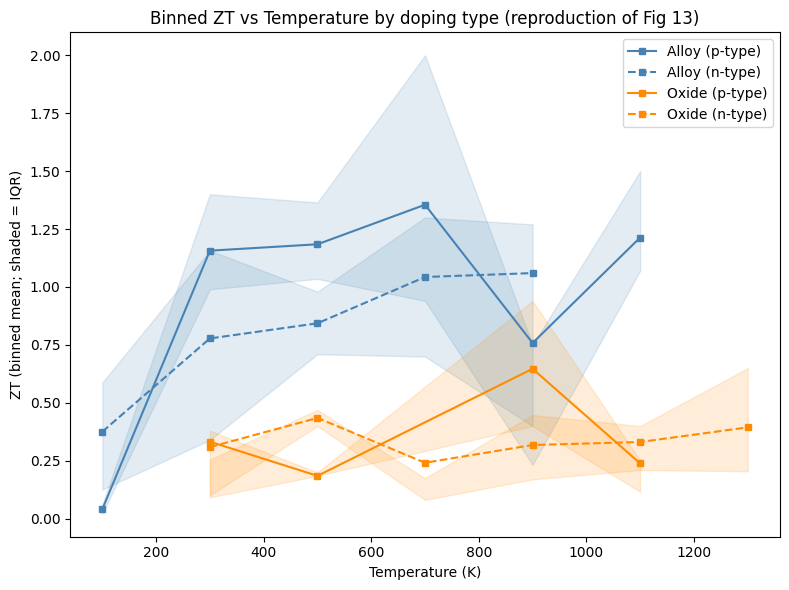

In [ ]:
def normalize_doping(s):
    if not isinstance(s, str):
        return None
    x = s.strip().lower()
    if x in ('p-type', 'p'):
        return 'p-type'
    if x in ('n-type', 'n'):
        return 'n-type'
    return None   # everything else (mixed, none, substitutional...) excluded from this figure, as in the paper

records13 = []
for _, row in df.iterrows():
    ctype = row['compound_type']
    if pd.isna(ctype):
        continue
    ctype = str(ctype).strip().lower()
    if ctype not in ('alloy', 'oxide'):
        continue
    dtype = normalize_doping(row['doping.doping_type'])
    if dtype is None:
        continue
    for t, zt in get_zt_points(row):
        records13.append({'compound_type': ctype, 'T': t, 'ZT': zt, 'doping_type': dtype})

fig13_df = pd.DataFrame(records13)

bin_edges = [0,200,400,600,800,1000,1200,1400]
bin_centers = [100,300,500,700,900,1100,1300]
fig13_df['T_bin'] = pd.cut(fig13_df['T'], bins=bin_edges, labels=bin_centers).astype(float)

plt.figure(figsize=(8,6))
styles = {
    ('alloy','p-type'): dict(color='steelblue', ls='-',  label='Alloy (p-type)'),
    ('alloy','n-type'): dict(color='steelblue', ls='--', label='Alloy (n-type)'),
    ('oxide','p-type'): dict(color='darkorange', ls='-',  label='Oxide (p-type)'),
    ('oxide','n-type'): dict(color='darkorange', ls='--', label='Oxide (n-type)'),
}
for (ctype, dtype), style in styles.items():
    sub = fig13_df[(fig13_df['compound_type']==ctype) & (fig13_df['doping_type']==dtype)]
    g = sub.groupby('T_bin')['ZT'].agg(
        mean='mean',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n='count'
    )
    g = g[g['n'] >= 2].sort_index()    # need ≥2 points to plot an IQR band meaningfully
    if len(g) == 0:
        continue
    plt.plot(g.index, g['mean'], **style, marker='s', markersize=4)
    plt.fill_between(g.index, g['q25'], g['q75'], color=style['color'], alpha=0.15)

plt.xlabel('Temperature (K)')
plt.ylabel('ZT (binned mean; shaded = IQR)')
plt.title('Binned ZT vs Temperature by doping type (reproduction of Fig 13)')
plt.legend()
plt.tight_layout()
plt.show()